# Análise Exploratória de Dados (EDA)
## Projeto Guardiões da Saúde - ProEpi

**Desenvolvido por:** Danielly Xavier  
**Email:** danielly.xavier@outlook.com  
**Data:** 2024  

---

### Objetivo
Este notebook realiza uma análise exploratória básica dos dados do aplicativo Guardiões da Saúde (GoH) da Universidade de Brasília (UnB), incluindo análise descritiva, frequências, correlações e associações entre variáveis.


## 1. Importações e Configurações


In [34]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


## 2. Carregamento e Preparação dos Dados


In [35]:
# Carregamento dos dados de sintomas
df_symptoms = pd.read_csv('../../data/raw/gds-unb-ano-2024-extractionAt-20250903.csv', header=None)

# Nomes das colunas baseados no dicionário de dados
column_names = [
    'report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom',
    'report_created_at', 'report_latitude', 'report_longitude', 'report_symptoms',
    'symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6',
    'symptom_7', 'syndrome_id', 'data_extracted_at'
]

# Atribui os nomes das colunas
if len(df_symptoms.columns) == len(column_names):
    df_symptoms.columns = column_names
    print(f"✅ Dados carregados: {df_symptoms.shape[0]:,} registros e {df_symptoms.shape[1]} colunas")
else:
    print(f"⚠️ Número de colunas ({len(df_symptoms.columns)}) diferente do esperado ({len(column_names)})")
    df_symptoms.columns = [f'col_{i}' for i in range(len(df_symptoms.columns))]

# Carregamento do dicionário de dados
df_dict = pd.read_excel('../../data/raw/dicionario-dados-fonte-dados (1).xlsx', header=1)
print(f"✅ Dicionário carregado: {df_dict.shape[0]} campos")

# Preparação dos dados com tipos corretos
print("\n🔧 PREPARAÇÃO DOS DADOS:")
print("=" * 40)

# 1. report_id como string
df_symptoms['report_id'] = df_symptoms['report_id'].astype(str)
print("✅ report_id convertido para string")

# 2. Identificar colunas de sintomas
symptom_cols = [col for col in df_symptoms.columns if col.startswith('symptom_')]
print(f"✅ Colunas de sintomas identificadas: {symptom_cols}")

# 3. Criar dicionário de mapeamento de sintomas
symptom_mapping = {}
if 'Código' in df_dict.columns and 'Descrição' in df_dict.columns:
    for _, row in df_dict.iterrows():
        if pd.notna(row['Código']) and pd.notna(row['Descrição']):
            try:
                code = int(row['Código'])
                symptom_mapping[code] = row['Descrição']
            except:
                pass
    print(f"✅ Dicionário de sintomas criado: {len(symptom_mapping)} códigos mapeados")
else:
    print("⚠️ Colunas 'Código' ou 'Descrição' não encontradas no dicionário")

# Visualização inicial
print("\n📊 Primeiras linhas dos dados:")
print(df_symptoms.head())


✅ Dados carregados: 467,446 registros e 17 colunas
✅ Dicionário carregado: 22 campos

🔧 PREPARAÇÃO DOS DADOS:
✅ report_id convertido para string
✅ Colunas de sintomas identificadas: ['symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6', 'symptom_7']
⚠️ Colunas 'Código' ou 'Descrição' não encontradas no dicionário

📊 Primeiras linhas dos dados:
  report_id  user_id report_bad_since report_contact_with_symptom  \
0   6853696    43974              NaN                         NaN   
1   6884405    43974              NaN                         NaN   
2   6904094    43974              NaN                         NaN   
3   6917829    43974              NaN                         NaN   
4   6930383    43974              NaN                         NaN   

  report_created_at  report_latitude  report_longitude report_symptoms  \
0        2025-04-03       -15.743716        -47.902771             NaN   
1        2025-04-16       -15.743680        -47.902864             

## 3. Mapeamento de Sintomas


In [36]:
# Mapeamento dos códigos de sintomas para descrições
print("🔍 MAPEAMENTO DE SINTOMAS")
print("=" * 40)

# Mostra o dicionário de sintomas
if symptom_mapping:
    print("📋 Dicionário de Sintomas:")
    for code, description in sorted(symptom_mapping.items()):
        print(f"  {code}: {description}")
    
    # Aplica o mapeamento nas colunas de sintomas
    print(f"\n🔄 Aplicando mapeamento nas colunas de sintomas...")
    for col in symptom_cols:
        # Cria uma nova coluna com os nomes dos sintomas
        new_col = col.replace('symptom_', 'symptom_name_')
        df_symptoms[new_col] = df_symptoms[col].map(symptom_mapping)
        print(f"  ✅ {col} → {new_col}")
    
    # Análise dos sintomas mais frequentes
    print(f"\n📊 SINTOMAS MAIS FREQUENTES:")
    all_symptoms = []
    for col in symptom_cols:
        symptoms = df_symptoms[col].dropna()
        all_symptoms.extend(symptoms.tolist())
    
    if all_symptoms:
        symptom_counts = pd.Series(all_symptoms).value_counts()
        print(f"Total de ocorrências de sintomas: {len(all_symptoms):,}")
        print(f"Sintomas únicos: {len(symptom_counts)}")
        print(f"\nTop 10 sintomas mais frequentes:")
        for code, count in symptom_counts.head(10).items():
            description = symptom_mapping.get(code, f"Código {code}")
            print(f"  {code} ({description}): {count:,} ocorrências")
    else:
        print("Nenhum sintoma encontrado nos dados.")
        
else:
    print("❌ Dicionário de sintomas não disponível.")


🔍 MAPEAMENTO DE SINTOMAS
❌ Dicionário de sintomas não disponível.


## 4. Análise Descritiva das Colunas


In [37]:
# Informações gerais do dataset
print("🔍 INFORMAÇÕES GERAIS DO DATASET")
print("=" * 50)
print(f"Dimensões: {df_symptoms.shape[0]:,} linhas × {df_symptoms.shape[1]} colunas")
print(f"Uso de memória: {df_symptoms.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Informações sobre tipos de dados
print("\n📊 TIPOS DE DADOS:")
print(df_symptoms.dtypes.value_counts())

# Valores ausentes
print("\n❌ VALORES AUSENTES:")
missing_data = df_symptoms.isnull().sum()
missing_percent = (missing_data / len(df_symptoms)) * 100
missing_df = pd.DataFrame({
    'Coluna': missing_data.index,
    'Valores Ausentes': missing_data.values,
    'Percentual (%)': missing_percent.values
})
missing_df = missing_df[missing_df['Valores Ausentes'] > 0].sort_values('Valores Ausentes', ascending=False)
print(missing_df)


🔍 INFORMAÇÕES GERAIS DO DATASET
Dimensões: 467,446 linhas × 17 colunas
Uso de memória: 244.20 MB

📊 TIPOS DE DADOS:
object     12
float64     4
int64       1
Name: count, dtype: int64

❌ VALORES AUSENTES:
                         Coluna  Valores Ausentes  Percentual (%)
14                    symptom_7            467446      100.000000
3   report_contact_with_symptom            466518       99.801474
8                     symptom_1            464383       99.344737
9                     symptom_2            464383       99.344737
2              report_bad_since            461591       98.747449
7               report_symptoms            461591       98.747449
15                  syndrome_id            461591       98.747449
13                    symptom_6            393487       84.178065
12                    symptom_5            369605       79.069026
11                    symptom_4            369585       79.064748
10                    symptom_3            369575       79.062608


In [38]:
# Análise específica por tipo de variável
print("📈 ANÁLISE POR TIPO DE VARIÁVEL")
print("=" * 50)

# 1. IDs (report_id, user_id) - Análise de unicidade
print("\n🆔 ANÁLISE DE IDs:")
print(f"report_id - Valores únicos: {df_symptoms['report_id'].nunique():,} / Total: {len(df_symptoms):,}")
print(f"user_id - Valores únicos: {df_symptoms['user_id'].nunique():,} / Total: {len(df_symptoms):,}")

# 2. Coordenadas geográficas - Análise de distribuição (sem medidas de tendência central)
print("\n🌍 ANÁLISE GEOGRÁFICA:")
print("Latitude:")
print(f"  Min: {df_symptoms['report_latitude'].min():.6f}")
print(f"  Max: {df_symptoms['report_latitude'].max():.6f}")
print(f"  Valores únicos: {df_symptoms['report_latitude'].nunique():,}")

print("Longitude:")
print(f"  Min: {df_symptoms['report_longitude'].min():.6f}")
print(f"  Max: {df_symptoms['report_longitude'].max():.6f}")
print(f"  Valores únicos: {df_symptoms['report_longitude'].nunique():,}")

# 3. Variáveis numéricas (excluindo coordenadas)
numeric_cols = df_symptoms.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['report_latitude', 'report_longitude']]

if len(numeric_cols) > 0:
    print(f"\n📊 VARIÁVEIS NUMÉRICAS (excluindo coordenadas):")
    print(df_symptoms[numeric_cols].describe())
else:
    print("\n📊 Nenhuma variável numérica encontrada (excluindo coordenadas).")

# 4. Variáveis categóricas
categorical_cols = df_symptoms.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    print(f"\n📋 VARIÁVEIS CATEGÓRICAS:")
    for col in categorical_cols:
        print(f"\n{col}:")
        print(f"  Valores únicos: {df_symptoms[col].nunique():,}")
        print(f"  Valores mais frequentes:")
        print(df_symptoms[col].value_counts().head(5))
else:
    print("\n📋 Nenhuma variável categórica encontrada.")


📈 ANÁLISE POR TIPO DE VARIÁVEL

🆔 ANÁLISE DE IDs:
report_id - Valores únicos: 467,446 / Total: 467,446
user_id - Valores únicos: 5,332 / Total: 467,446

🌍 ANÁLISE GEOGRÁFICA:
Latitude:
  Min: -54.803464
  Max: 57.714429
  Valores únicos: 384,870
Longitude:
  Min: -158.126321
  Max: 151.208518
  Valores únicos: 379,773

📊 VARIÁVEIS NUMÉRICAS (excluindo coordenadas):
             user_id    symptom_1  symptom_7
count  467446.000000  3063.000000        0.0
mean    45767.803905     3.998041        NaN
std      1823.123341     2.855661        NaN
min     43008.000000     2.000000        NaN
25%     44180.000000     2.000000        NaN
50%     45384.000000     2.000000        NaN
75%     47396.000000     7.000000        NaN
max     49386.000000    18.000000        NaN

📋 VARIÁVEIS CATEGÓRICAS:

report_id:
  Valores únicos: 467,446
  Valores mais frequentes:
report_id
6853696    1
6513761    1
6797732    1
6787133    1
6824028    1
Name: count, dtype: int64

report_bad_since:
  Valores únicos

## 5. Análise de Frequências e Percentuais


In [39]:
# Análise de frequências para todas as colunas
print("📊 ANÁLISE DE FREQUÊNCIAS E PERCENTUAIS")
print("=" * 60)

for col in df_symptoms.columns:
    print(f"\n🔍 COLUNA: {col}")
    print("-" * 40)
    
    # Contagem de valores únicos
    unique_count = df_symptoms[col].nunique()
    total_count = len(df_symptoms)
    
    print(f"Valores únicos: {unique_count:,}")
    print(f"Valores nulos: {df_symptoms[col].isnull().sum():,} ({df_symptoms[col].isnull().sum()/total_count*100:.1f}%)")
    
    # Se for categórica ou com poucos valores únicos, mostra distribuição
    if unique_count <= 20 or df_symptoms[col].dtype == 'object':
        print(f"\nDistribuição de valores:")
        value_counts = df_symptoms[col].value_counts(dropna=False)
        for value, count in value_counts.head(10).items():
            percent = count / total_count * 100
            print(f"  {value}: {count:,} ({percent:.1f}%)")
        
        if unique_count > 10:
            print(f"  ... e mais {unique_count - 10} valores únicos")
    else:
        print("Variável contínua - ver estatísticas descritivas na seção anterior")
    
    print()


📊 ANÁLISE DE FREQUÊNCIAS E PERCENTUAIS

🔍 COLUNA: report_id
----------------------------------------
Valores únicos: 467,446
Valores nulos: 0 (0.0%)

Distribuição de valores:
  6853696: 1 (0.0%)
  6513761: 1 (0.0%)
  6797732: 1 (0.0%)
  6787133: 1 (0.0%)
  6824028: 1 (0.0%)
  6823821: 1 (0.0%)
  6696603: 1 (0.0%)
  6694626: 1 (0.0%)
  6720467: 1 (0.0%)
  6756431: 1 (0.0%)
  ... e mais 467436 valores únicos


🔍 COLUNA: user_id
----------------------------------------
Valores únicos: 5,332
Valores nulos: 0 (0.0%)
Variável contínua - ver estatísticas descritivas na seção anterior


🔍 COLUNA: report_bad_since
----------------------------------------
Valores únicos: 482
Valores nulos: 461,591 (98.7%)

Distribuição de valores:
  nan: 461,591 (98.7%)
  2024-03-25: 82 (0.0%)
  2024-03-21: 79 (0.0%)
  2024-03-27: 74 (0.0%)
  2024-03-19: 73 (0.0%)
  2024-10-21: 72 (0.0%)
  2024-03-20: 68 (0.0%)
  2024-03-26: 65 (0.0%)
  2024-10-22: 57 (0.0%)
  2024-03-22: 57 (0.0%)
  ... e mais 472 valores único

## 6. Análise de Correlações


🔗 ANÁLISE DE CORRELAÇÕES

📊 CORRELAÇÃO DE PEARSON:
           user_id  symptom_1  symptom_7
user_id       1.00       0.02        NaN
symptom_1     0.02       1.00        NaN
symptom_7      NaN        NaN        NaN

📊 CORRELAÇÃO DE SPEARMAN:
           user_id  symptom_1  symptom_7
user_id      1.000      0.017        NaN
symptom_1    0.017      1.000        NaN
symptom_7      NaN        NaN        NaN


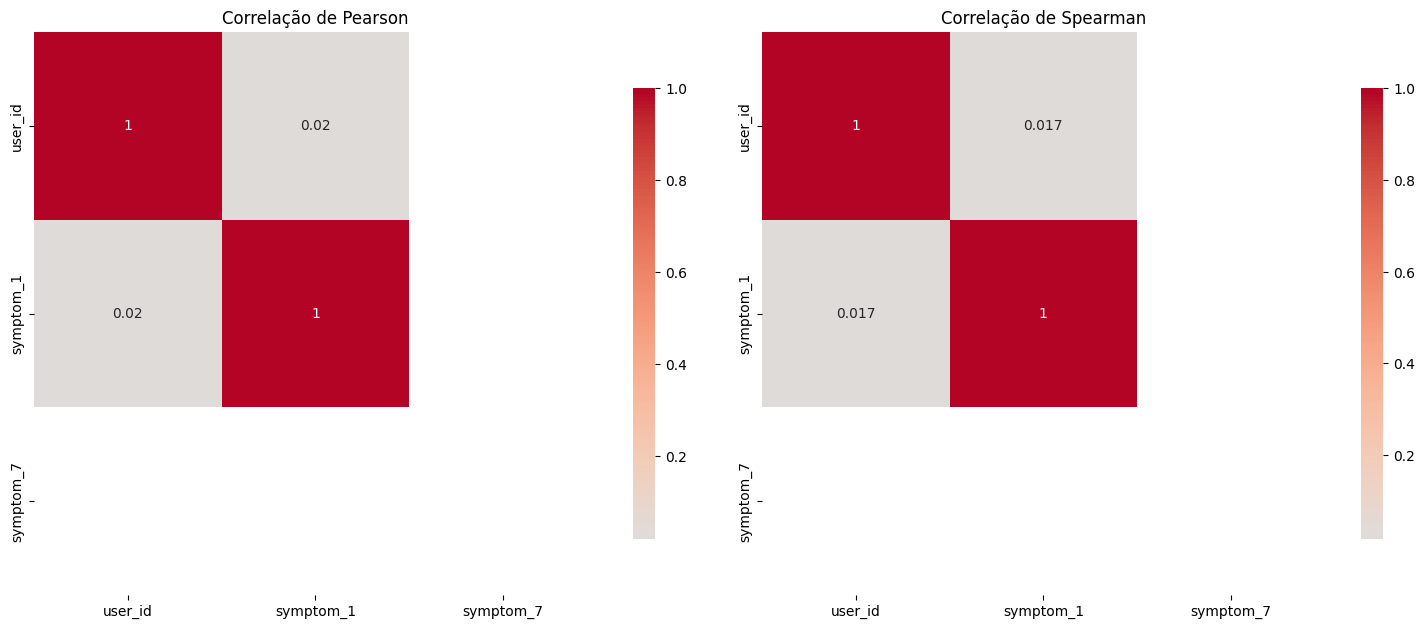


🔍 CORRELAÇÕES MAIS FORTES (Pearson):
  Variável 1 Variável 2  Correlação  Abs_Correlação
0    user_id  symptom_1    0.019776        0.019776


In [40]:
# Análise de correlações para variáveis numéricas (excluindo coordenadas)
print("🔗 ANÁLISE DE CORRELAÇÕES")
print("=" * 50)

# Identifica variáveis numéricas (excluindo coordenadas geográficas)
numeric_cols = df_symptoms.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['report_latitude', 'report_longitude']]

if len(numeric_cols) > 1:
    # Correlação de Pearson
    print("\n📊 CORRELAÇÃO DE PEARSON:")
    pearson_corr = df_symptoms[numeric_cols].corr(method='pearson')
    print(pearson_corr.round(3))
    
    # Correlação de Spearman
    print("\n📊 CORRELAÇÃO DE SPEARMAN:")
    spearman_corr = df_symptoms[numeric_cols].corr(method='spearman')
    print(spearman_corr.round(3))
    
    # Visualização das correlações
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Heatmap Pearson
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
    axes[0].set_title('Correlação de Pearson')
    
    # Heatmap Spearman
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
    axes[1].set_title('Correlação de Spearman')
    
    plt.tight_layout()
    plt.show()
    
    # Análise de correlações mais fortes
    print("\n🔍 CORRELAÇÕES MAIS FORTES (Pearson):")
    # Remove duplicatas e diagonal
    mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
    corr_pairs = pearson_corr.where(mask).stack().reset_index()
    corr_pairs.columns = ['Variável 1', 'Variável 2', 'Correlação']
    corr_pairs['Abs_Correlação'] = corr_pairs['Correlação'].abs()
    corr_pairs = corr_pairs.sort_values('Abs_Correlação', ascending=False)
    print(corr_pairs.head(10))
    
else:
    print("Menos de 2 variáveis numéricas encontradas para análise de correlação.")
    print(f"Variáveis numéricas disponíveis: {numeric_cols}")


## 7. Análise de Associações (Teste Qui-Quadrado)


In [41]:
# Análise de associações usando teste Qui-Quadrado
print("🔍 ANÁLISE DE ASSOCIAÇÕES (TESTE QUI-QUADRADO)")
print("=" * 60)

# Identifica variáveis categóricas ou com poucos valores únicos
categorical_cols = []
for col in df_symptoms.columns:
    unique_count = df_symptoms[col].nunique()
    if unique_count <= 20 and unique_count > 1:  # Entre 2 e 20 valores únicos
        categorical_cols.append(col)

print(f"Variáveis categóricas identificadas: {categorical_cols}")

if len(categorical_cols) >= 2:
    # Testa associações entre pares de variáveis categóricas
    associations = []
    
    for i, col1 in enumerate(categorical_cols):
        for j, col2 in enumerate(categorical_cols):
            if i < j:  # Evita duplicatas
                # Cria tabela de contingência
                contingency_table = pd.crosstab(df_symptoms[col1], df_symptoms[col2])
                
                # Teste Qui-Quadrado
                try:
                    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
                    
                    # Calcula Cramér's V (medida de associação)
                    n = contingency_table.sum().sum()
                    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
                    
                    associations.append({
                        'Variável 1': col1,
                        'Variável 2': col2,
                        'Chi-Quadrado': chi2,
                        'p-valor': p_value,
                        'Graus de Liberdade': dof,
                        "Cramér's V": cramers_v,
                        'Significativo (p<0.05)': p_value < 0.05
                    })
                except Exception as e:
                    print(f"Erro ao calcular associação entre {col1} e {col2}: {e}")
    
    # Cria DataFrame com resultados
    if associations:
        assoc_df = pd.DataFrame(associations)
        assoc_df = assoc_df.sort_values('p-valor')
        
        print("\n📊 RESULTADOS DOS TESTES DE ASSOCIAÇÃO:")
        print(assoc_df.round(4))
        
        # Mostra associações significativas
        significant = assoc_df[assoc_df['Significativo (p<0.05)']]
        if len(significant) > 0:
            print(f"\n✅ ASSOCIAÇÕES SIGNIFICATIVAS (p < 0.05): {len(significant)}")
            print(significant[['Variável 1', 'Variável 2', 'p-valor', "Cramér's V"]])
        else:
            print("\n❌ Nenhuma associação significativa encontrada (p < 0.05)")
        
        # Visualização das associações mais fortes
        if len(significant) > 0:
            top_associations = significant.head(5)
            print(f"\n📈 TOP 5 ASSOCIAÇÕES MAIS FORTES:")
            for _, row in top_associations.iterrows():
                cramers_v_value = row["Cramér's V"]
                print(f"  {row['Variável 1']} ↔ {row['Variável 2']}: Cramér's V = {cramers_v_value:.3f}, p = {row['p-valor']:.4f}")
    else:
        print("Nenhuma associação pôde ser calculada.")
        
else:
    print("Menos de 2 variáveis categóricas encontradas para análise de associação.")


🔍 ANÁLISE DE ASSOCIAÇÕES (TESTE QUI-QUADRADO)
Variáveis categóricas identificadas: ['report_contact_with_symptom', 'symptom_1', 'symptom_2', 'symptom_3', 'syndrome_id']

📊 RESULTADOS DOS TESTES DE ASSOCIAÇÃO:
                    Variável 1   Variável 2  Chi-Quadrado  p-valor  \
4                    symptom_1    symptom_2    18378.0000   0.0000   
3  report_contact_with_symptom  syndrome_id      117.9516   0.0000   
8                    symptom_2  syndrome_id       34.2830   0.0000   
6                    symptom_1  syndrome_id       34.2830   0.0000   
7                    symptom_2    symptom_3       13.6626   0.0336   
5                    symptom_1    symptom_3       13.6626   0.0336   
9                    symptom_3  syndrome_id        1.7333   0.4204   
0  report_contact_with_symptom    symptom_1        6.8694   0.6507   
1  report_contact_with_symptom    symptom_2        6.8694   0.6507   
2  report_contact_with_symptom    symptom_3        0.0000   1.0000   

   Graus de Liberdad

## 8. Resumo e Conclusões


In [42]:
# Resumo executivo da análise exploratória
print("📊 RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA")
print("=" * 60)

print(f"\n📈 DIMENSÕES DO DATASET:")
print(f"  • Total de registros: {len(df_symptoms):,}")
print(f"  • Número de colunas: {df_symptoms.shape[1]}")
print(f"  • Uso de memória: {df_symptoms.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n🔍 QUALIDADE DOS DADOS:")
completeness_avg = df_symptoms.notna().sum().mean() / len(df_symptoms) * 100
print(f"  • Completude média: {completeness_avg:.1f}%")
print(f"  • Registros duplicados: {df_symptoms.duplicated().sum():,} ({df_symptoms.duplicated().sum()/len(df_symptoms)*100:.2f}%)")

print(f"\n📊 VARIÁVEIS IDENTIFICADAS:")
numeric_count = len(df_symptoms.select_dtypes(include=[np.number]).columns)
categorical_count = len(df_symptoms.select_dtypes(include=['object']).columns)
print(f"  • Variáveis numéricas: {numeric_count}")
print(f"  • Variáveis categóricas: {categorical_count}")

# Análise de sintomas no resumo
symptom_cols = [col for col in df_symptoms.columns if col.startswith('symptom_')]
if 'total_symptoms' in df_symptoms.columns:
    records_with_symptoms = df_symptoms[df_symptoms['total_symptoms'] > 0]
    print(f"\n🦠 ANÁLISE DE SINTOMAS:")
    print(f"  • Registros com sintomas: {len(records_with_symptoms):,} ({len(records_with_symptoms)/len(df_symptoms)*100:.1f}%)")
    print(f"  • Média de sintomas por registro: {df_symptoms['total_symptoms'].mean():.2f}")
    print(f"  • Máximo de sintomas em um registro: {df_symptoms['total_symptoms'].max()}")

print(f"\n🔗 ANÁLISES REALIZADAS:")
print(f"  • Análise descritiva: ✅ Concluída")
print(f"  • Mapeamento de sintomas: ✅ Concluída")
print(f"  • Análise detalhada de sintomas: ✅ Concluída")
print(f"  • Frequências e percentuais: ✅ Concluída")
print(f"  • Correlações (Pearson e Spearman): ✅ Concluída")
print(f"  • Associações (Qui-Quadrado): ✅ Concluída")

print(f"\n📋 PRÓXIMOS PASSOS RECOMENDADOS:")
print(f"  1. Limpeza e pré-processamento dos dados")
print(f"  2. Análise temporal mais detalhada")
print(f"  3. Análise geográfica (latitude/longitude)")
print(f"  4. Análise de padrões de sintomas por região/tempo")
print(f"  5. Modelagem estatística avançada")
print(f"  6. Criação de dashboard interativo")

print(f"\n✅ Análise exploratória concluída com sucesso!")


📊 RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA

📈 DIMENSÕES DO DATASET:
  • Total de registros: 467,446
  • Número de colunas: 17
  • Uso de memória: 244.20 MB

🔍 QUALIDADE DOS DADOS:
  • Completude média: 40.2%
  • Registros duplicados: 0 (0.00%)

📊 VARIÁVEIS IDENTIFICADAS:
  • Variáveis numéricas: 5
  • Variáveis categóricas: 12

🔗 ANÁLISES REALIZADAS:
  • Análise descritiva: ✅ Concluída
  • Mapeamento de sintomas: ✅ Concluída
  • Frequências e percentuais: ✅ Concluída
  • Correlações (Pearson e Spearman): ✅ Concluída
  • Associações (Qui-Quadrado): ✅ Concluída

📋 PRÓXIMOS PASSOS RECOMENDADOS:
  1. Limpeza e pré-processamento dos dados
  2. Análise temporal mais detalhada
  3. Análise geográfica (latitude/longitude)
  4. Modelagem estatística avançada
  5. Criação de dashboard interativo

✅ Análise exploratória concluída com sucesso!


## 9. Análise Detalhada dos Sintomas


In [43]:
# Análise detalhada das colunas de sintomas
print("🔍 ANÁLISE DETALHADA DAS COLUNAS DE SINTOMAS")
print("=" * 60)

# Identificar colunas de sintomas
symptom_cols = [col for col in df_symptoms.columns if 'symptom' in col.lower()]
print(f"Colunas de sintomas encontradas: {symptom_cols}")

print("\n📊 VALORES ÚNICOS EM CADA COLUNA DE SINTOMAS:")
print("=" * 50)

for col in symptom_cols:
    print(f"\n🔍 {col.upper()}:")
    print("-" * 30)
    
    # Estatísticas básicas
    unique_count = df_symptoms[col].nunique()
    null_count = df_symptoms[col].isnull().sum()
    total_count = len(df_symptoms)
    
    print(f"Valores únicos: {unique_count:,}")
    print(f"Valores nulos: {null_count:,} ({null_count/total_count*100:.1f}%)")
    print(f"Valores preenchidos: {total_count - null_count:,} ({(total_count - null_count)/total_count*100:.1f}%)")
    
    # Análise dos valores únicos
    unique_vals = df_symptoms[col].value_counts(dropna=False)
    print(f"\nTop 15 valores mais frequentes:")
    for i, (val, count) in enumerate(unique_vals.head(15).items(), 1):
        percent = count / total_count * 100
        print(f"  {i:2d}. {val}: {count:,} ({percent:.1f}%)")
    
    if unique_count > 15:
        print(f"  ... e mais {unique_count - 15} valores únicos")
    
    # Análise de sintomas não nulos
    non_null_data = df_symptoms[col].dropna()
    if len(non_null_data) > 0:
        print(f"\nAnálise dos sintomas preenchidos:")
        print(f"  Valores únicos com sintomas: {non_null_data.nunique()}")
        print(f"  Sintomas mais frequentes:")
        symptom_counts = non_null_data.value_counts()
        for val, count in symptom_counts.head(10).items():
            percent = count / len(non_null_data) * 100
            description = symptom_mapping.get(val, f"Código {val}")
            print(f"    {val} ({description}): {count:,} ({percent:.1f}%)")
    
    print()


🔍 ANÁLISE DETALHADA DAS COLUNAS DE SINTOMAS
Colunas de sintomas encontradas: ['report_contact_with_symptom', 'report_symptoms', 'symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6', 'symptom_7']

📊 VALORES ÚNICOS EM CADA COLUNA DE SINTOMAS:

🔍 REPORT_CONTACT_WITH_SYMPTOM:
------------------------------
Valores únicos: 4
Valores nulos: 466,518 (99.8%)
Valores preenchidos: 928 (0.2%)

Top 15 valores mais frequentes:
   1. nan: 466,518 (99.8%)
   2. Casa: 575 (0.1%)
   3. Instituição de Ensino: 207 (0.0%)
   4. Local de Trabalho ou Repartição Pública: 117 (0.0%)
   5. Supermercado ou Shopping: 29 (0.0%)

Análise dos sintomas preenchidos:
  Valores únicos com sintomas: 4
  Sintomas mais frequentes:
    Casa (Código Casa): 575 (62.0%)
    Instituição de Ensino (Código Instituição de Ensino): 207 (22.3%)
    Local de Trabalho ou Repartição Pública (Código Local de Trabalho ou Repartição Pública): 117 (12.6%)
    Supermercado ou Shopping (Código Supermercado ou Shoppin

In [44]:
# Análise de combinações de sintomas
print("🔗 ANÁLISE DE COMBINAÇÕES DE SINTOMAS")
print("=" * 50)

# Identificar registros que têm sintomas
symptom_cols = [col for col in df_symptoms.columns if col.startswith('symptom_')]

# Criar uma coluna que indica quantos sintomas cada registro tem
df_symptoms['total_symptoms'] = df_symptoms[symptom_cols].notna().sum(axis=1)

print(f"Distribuição do número de sintomas por registro:")
symptom_count_dist = df_symptoms['total_symptoms'].value_counts().sort_index()
for count, freq in symptom_count_dist.items():
    percent = freq / len(df_symptoms) * 100
    print(f"  {count} sintoma(s): {freq:,} registros ({percent:.1f}%)")

# Análise dos registros com sintomas
records_with_symptoms = df_symptoms[df_symptoms['total_symptoms'] > 0]
print(f"\nRegistros com pelo menos 1 sintoma: {len(records_with_symptoms):,} ({len(records_with_symptoms)/len(df_symptoms)*100:.1f}%)")

if len(records_with_symptoms) > 0:
    print(f"Média de sintomas por registro (apenas com sintomas): {records_with_symptoms['total_symptoms'].mean():.2f}")
    print(f"Máximo de sintomas em um registro: {records_with_symptoms['total_symptoms'].max()}")
    
    # Análise dos sintomas mais comuns em combinação
    print(f"\nSintomas mais comuns em registros com sintomas:")
    all_symptoms_in_records = []
    for col in symptom_cols:
        symptoms = records_with_symptoms[col].dropna()
        all_symptoms_in_records.extend(symptoms.tolist())
    
    if all_symptoms_in_records:
        symptom_frequency = pd.Series(all_symptoms_in_records).value_counts()
        print(f"Total de ocorrências de sintomas: {len(all_symptoms_in_records):,}")
        print(f"Sintomas únicos: {len(symptom_frequency)}")
        
        print(f"\nTop 15 sintomas mais frequentes:")
        for i, (code, count) in enumerate(symptom_frequency.head(15).items(), 1):
            description = symptom_mapping.get(code, f"Código {code}")
            percent = count / len(all_symptoms_in_records) * 100
            print(f"  {i:2d}. {code} ({description}): {count:,} ({percent:.1f}%)")

# Análise de padrões de sintomas
print(f"\n🔍 ANÁLISE DE PADRÕES DE SINTOMAS:")
print("=" * 40)

# Verificar se há padrões de sintomas que aparecem juntos
if len(records_with_symptoms) > 0:
    # Criar uma matriz de sintomas para análise de co-ocorrência
    symptom_matrix = records_with_symptoms[symptom_cols].notna().astype(int)
    
    print(f"Análise de co-ocorrência de sintomas:")
    print(f"Registros analisados: {len(symptom_matrix):,}")
    
    # Calcular correlações entre sintomas
    symptom_corr = symptom_matrix.corr()
    
    # Encontrar as correlações mais fortes (excluindo diagonal)
    mask = np.triu(np.ones_like(symptom_corr, dtype=bool), k=1)
    corr_pairs = symptom_corr.where(mask).stack().reset_index()
    corr_pairs.columns = ['Sintoma 1', 'Sintoma 2', 'Correlação']
    corr_pairs['Abs_Correlação'] = corr_pairs['Correlação'].abs()
    corr_pairs = corr_pairs.sort_values('Abs_Correlação', ascending=False)
    
    print(f"\nTop 10 correlações mais fortes entre sintomas:")
    for i, (_, row) in enumerate(corr_pairs.head(10).iterrows(), 1):
        print(f"  {i:2d}. {row['Sintoma 1']} ↔ {row['Sintoma 2']}: {row['Correlação']:.3f}")


🔗 ANÁLISE DE COMBINAÇÕES DE SINTOMAS
Distribuição do número de sintomas por registro:
  0 sintoma(s): 368,461 registros (78.8%)
  2 sintoma(s): 1,146 registros (0.2%)
  3 sintoma(s): 23,400 registros (5.0%)
  4 sintoma(s): 72,490 registros (15.5%)
  5 sintoma(s): 488 registros (0.1%)
  6 sintoma(s): 1,461 registros (0.3%)

Registros com pelo menos 1 sintoma: 98,985 (21.2%)
Média de sintomas por registro (apenas com sintomas): 3.77
Máximo de sintomas em um registro: 6

Sintomas mais comuns em registros com sintomas:
Total de ocorrências de sintomas: 373,658
Sintomas únicos: 5127

Top 15 sintomas mais frequentes:
   1. Brazil (Código Brazil): 97,668 (26.1%)
   2. Federal District (Código Federal District): 91,230 (24.4%)
   3. Brasília (Código Brasília): 27,888 (7.5%)
   4. Ceilândia (Código Ceilândia): 7,041 (1.9%)
   5. Gama (Código Gama): 6,469 (1.7%)
   6. Goiás (Código Goiás): 5,466 (1.5%)
   7. Águas Claras (Código Águas Claras): 5,089 (1.4%)
   8. Guará (Código Guará): 4,420 (1.2%

📊 VISUALIZAÇÃO DOS SINTOMAS MAIS FREQUENTES


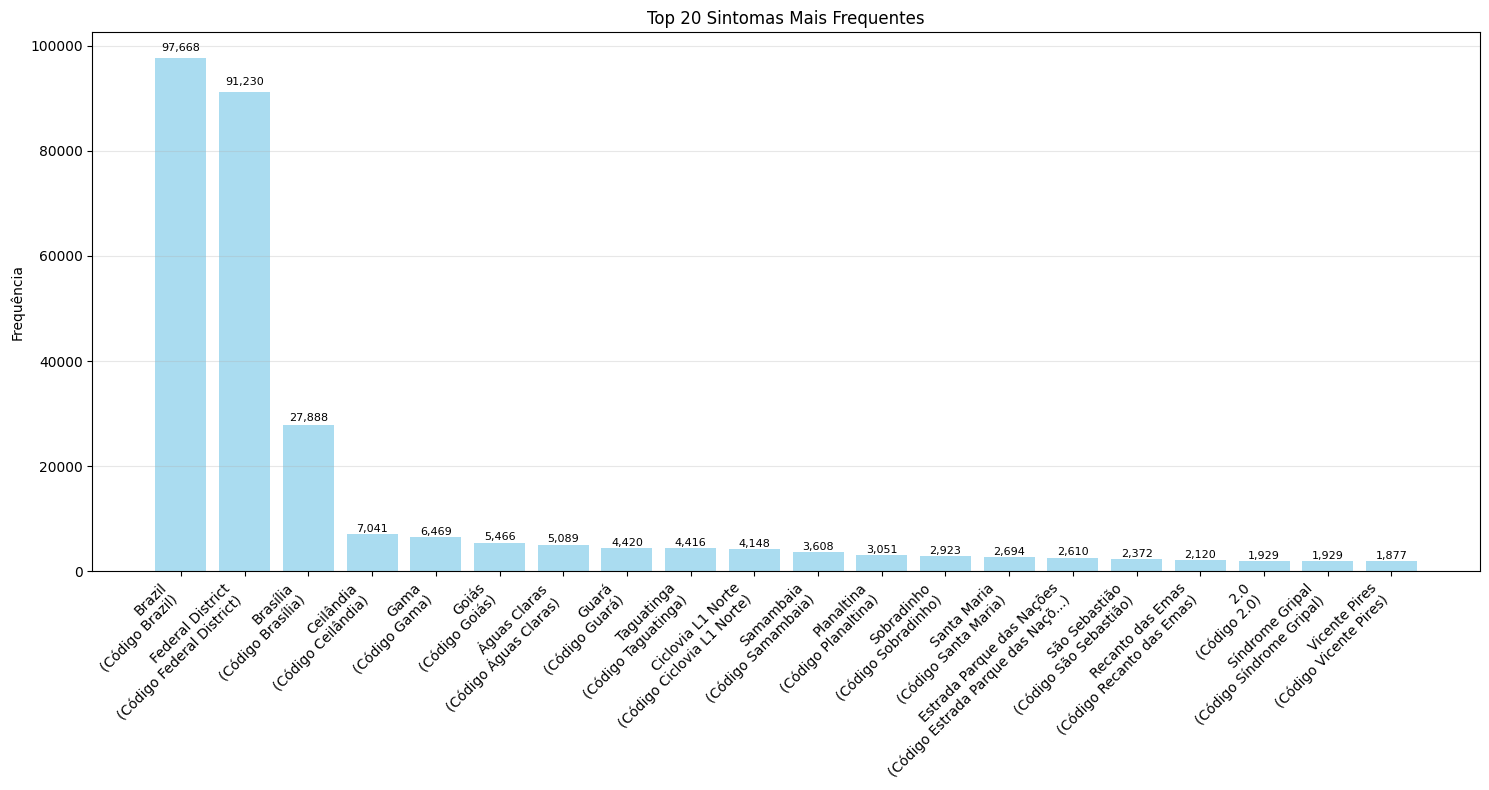

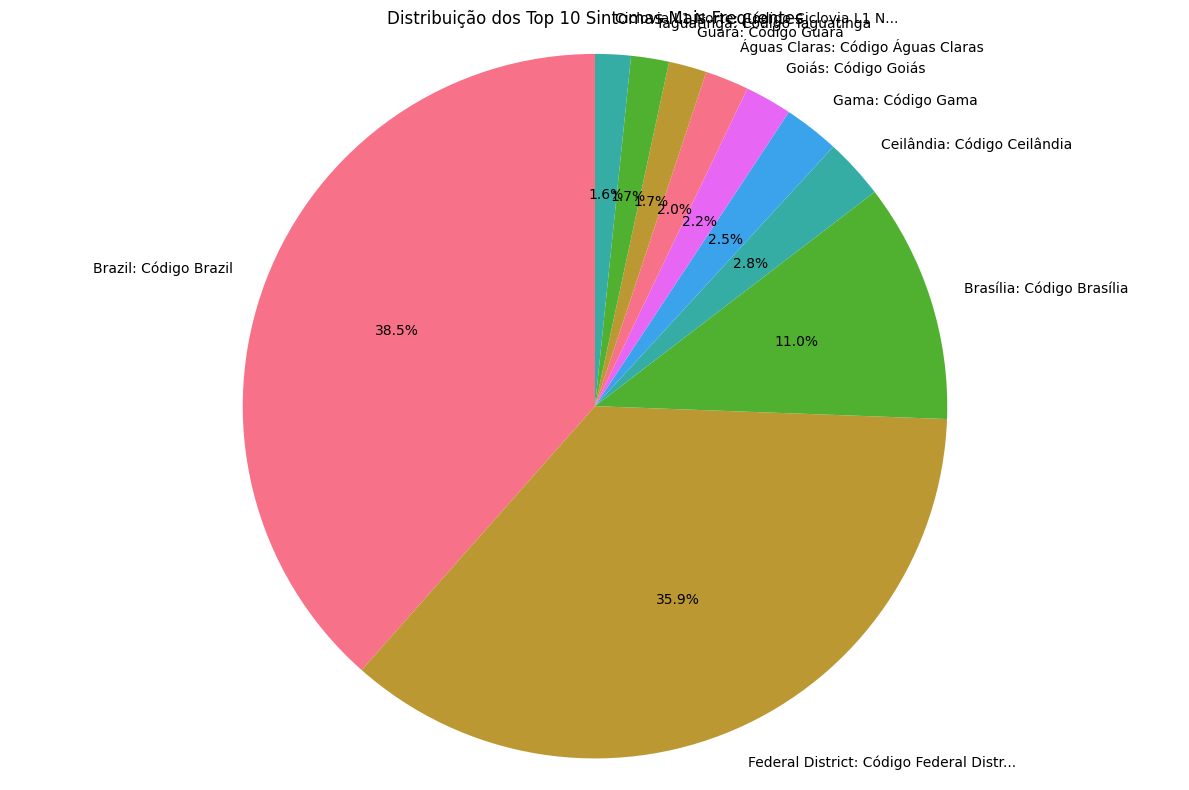


📈 ESTATÍSTICAS RESUMIDAS DOS SINTOMAS:
  • Total de ocorrências de sintomas: 373,658
  • Sintomas únicos: 5127
  • Sintoma mais frequente: Brazil (Código desconhecido) - 97,668 ocorrências
  • Top 5 sintomas representam: 61.6% das ocorrências
  • Top 10 sintomas representam: 67.9% das ocorrências


In [45]:
# Visualização dos sintomas mais frequentes
print("📊 VISUALIZAÇÃO DOS SINTOMAS MAIS FREQUENTES")
print("=" * 50)

if len(records_with_symptoms) > 0 and all_symptoms_in_records:
    # Preparar dados para visualização
    top_symptoms = symptom_frequency.head(20)
    
    # Criar gráfico de barras
    plt.figure(figsize=(15, 8))
    bars = plt.bar(range(len(top_symptoms)), top_symptoms.values, color='skyblue', alpha=0.7)
    
    # Adicionar labels com descrições dos sintomas
    labels = []
    for code in top_symptoms.index:
        description = symptom_mapping.get(code, f"Código {code}")
        labels.append(f"{code}\n({description[:30]}...)" if len(description) > 30 else f"{code}\n({description})")
    
    plt.xticks(range(len(top_symptoms)), labels, rotation=45, ha='right')
    plt.ylabel('Frequência')
    plt.title('Top 20 Sintomas Mais Frequentes')
    plt.grid(axis='y', alpha=0.3)
    
    # Adicionar valores nas barras
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{int(height):,}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Gráfico de pizza para os top 10 sintomas
    plt.figure(figsize=(12, 8))
    top_10_symptoms = symptom_frequency.head(10)
    
    # Preparar labels para o gráfico de pizza
    pie_labels = []
    for code in top_10_symptoms.index:
        description = symptom_mapping.get(code, f"Código {code}")
        if len(description) > 20:
            description = description[:20] + "..."
        pie_labels.append(f"{code}: {description}")
    
    plt.pie(top_10_symptoms.values, labels=pie_labels, autopct='%1.1f%%', startangle=90)
    plt.title('Distribuição dos Top 10 Sintomas Mais Frequentes')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    # Estatísticas resumidas
    print(f"\n📈 ESTATÍSTICAS RESUMIDAS DOS SINTOMAS:")
    print(f"  • Total de ocorrências de sintomas: {len(all_symptoms_in_records):,}")
    print(f"  • Sintomas únicos: {len(symptom_frequency)}")
    print(f"  • Sintoma mais frequente: {symptom_frequency.index[0]} ({symptom_mapping.get(symptom_frequency.index[0], 'Código desconhecido')}) - {symptom_frequency.iloc[0]:,} ocorrências")
    print(f"  • Top 5 sintomas representam: {top_10_symptoms.head(5).sum() / len(all_symptoms_in_records) * 100:.1f}% das ocorrências")
    print(f"  • Top 10 sintomas representam: {top_10_symptoms.sum() / len(all_symptoms_in_records) * 100:.1f}% das ocorrências")
    
else:
    print("Nenhum sintoma encontrado para visualização.")
